# xfig_04 — Deployment Scenario Heatmap

For a given **recording budget** (columns) and **required AUROC** (rows): what is the best achievable AUROC and which (L, K) configuration achieves it?

Each panel = one task. Cells show the best AUROC achievable with that budget
and the (L, K) configuration. Green = target met; red = target not met.

Idea #4 from `docs/NEW_PLOT_IDEAS.md`.

**Data**: `heatmap_df_test.csv` (dense K sweep) per task.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

# ── Workspace root: auto-detect by looking for final_results/ ─────────────────
def _find_workspace():
    candidate = Path.cwd().resolve()
    for _ in range(10):
        if (candidate / "final_results").exists():
            return candidate
        if candidate.parent == candidate:
            break
        candidate = candidate.parent
    return Path("/Users/boshra/NSRR-workspace").resolve()

WORKSPACE_ROOT = _find_workspace()
NSRR_TOOLS     = WORKSPACE_ROOT / "NSRR-tools"
EXPLORE_DIR    = NSRR_TOOLS / "results" / "paper_figures" / "explore"
FINAL_OUT      = EXPLORE_DIR / "final"
FINAL_OUT.mkdir(parents=True, exist_ok=True)
TABLES_DIR     = NSRR_TOOLS / "results" / "tables"

# Add explore utils to path
_nb_dir = EXPLORE_DIR / "notebooks"
sys.path.insert(0, str(_nb_dir))

from utils.data_explore import (
    set_root, load_analysis, load_analysis_all_k,
    load_heatmap, load_parquets, load_modality_table,
    subject_predictions, subject_correctness_matrix, CONTEXT_TO_MIN, CTX_ORDER,
)
from utils import panels_explore as xp

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns

set_root(WORKSPACE_ROOT)
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": 7,
})

# ── Constants ──────────────────────────────────────────────────────────────────
MAIN_TASKS = ["sex_binary", "bmi_binary", "age_class",
              "sleep_efficiency_binary", "apnea_binary"]
TASK_LABEL = xp.TASK_LABEL

_ok = (WORKSPACE_ROOT / "final_results").exists()
print(f"WORKSPACE_ROOT : {WORKSPACE_ROOT}")
print(f"final_results/ : {'✓ found' if _ok else '✗ NOT FOUND'}")


WORKSPACE_ROOT : /Users/boshra/NSRR-workspace
final_results/ : ✓ found


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
TASKS   = MAIN_TASKS
HEAD    = "transformer"
BUDGETS = [30, 60, 120, 240, 480]     # total signal minutes
TARGETS = [0.70, 0.75, 0.80, 0.85]   # required AUROC

hmaps = {t: load_heatmap("phase0_v3", t, HEAD) for t in TASKS}
print("Heatmap sizes:", {t: len(v) for t, v in hmaps.items()})

Heatmap sizes: {'sex_binary': 76, 'bmi_binary': 81, 'age_class': 81, 'sleep_efficiency_binary': 85, 'apnea_binary': 81}


/var/folders/_j/pvy19dq529559q352v51y7_00000gn/T/ipykernel_5573/3506045020.py:20: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.tight_layout(h_pad=1.5, w_pad=1.2)
/Users/boshra/NSRR-workspace/NSRR-tools/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


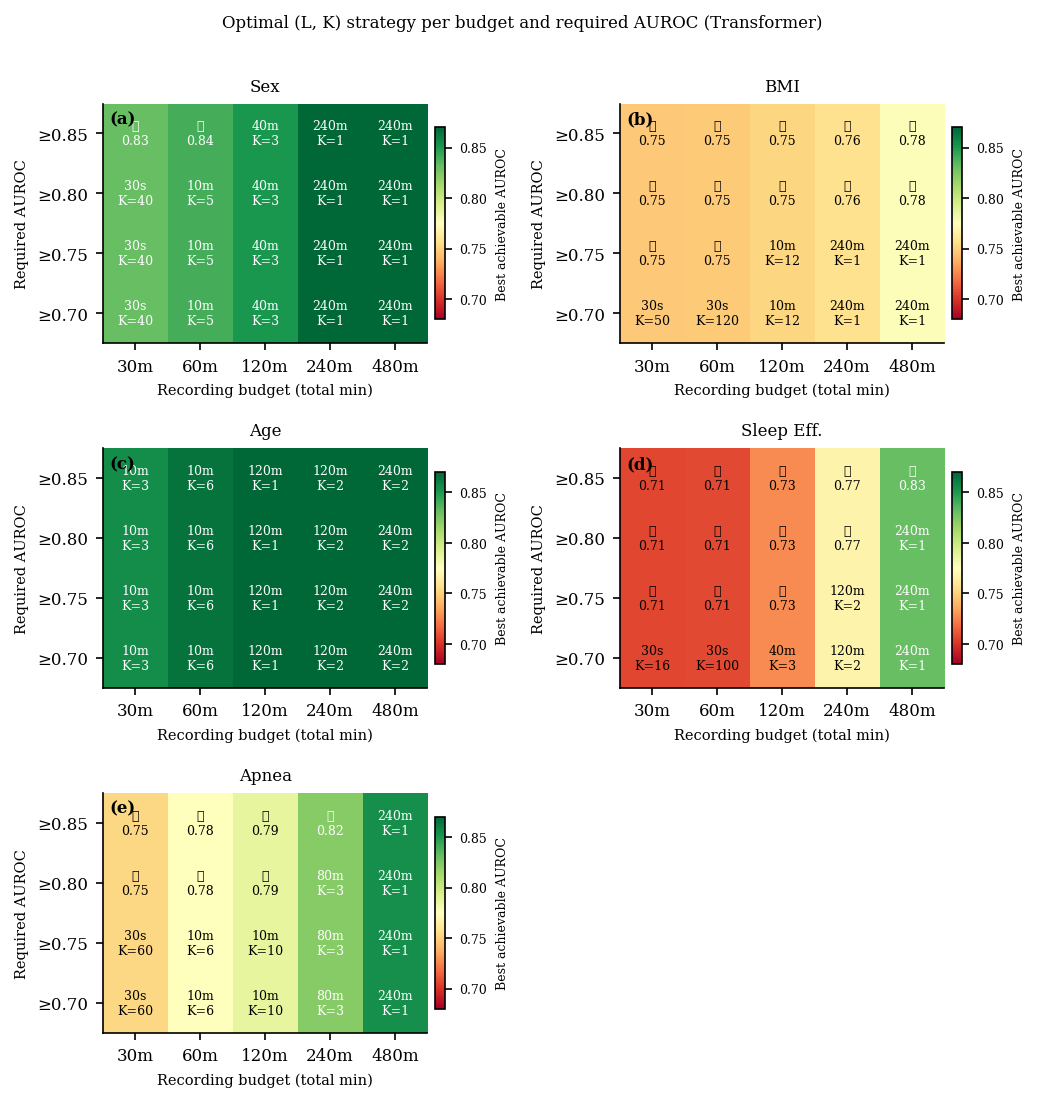

In [5]:
N_COLS = 2
N_ROWS = (len(TASKS) + N_COLS - 1) // N_COLS
ROW_H  = 2.4

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(7.0, N_ROWS * ROW_H))
axes_flat = axes.flatten()

for i, (ax, task) in enumerate(zip(axes_flat, TASKS)):
    xp.deployment_scenario_panel(ax, hmaps[task], task,
                                  budgets_min=BUDGETS, targets=TARGETS)
    ax.set_title(TASK_LABEL.get(task, task), fontsize=8)
    ax.text(0.02, 0.97, f"({chr(97+i)})", transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top")

for ax in axes_flat[len(TASKS):]:
    ax.set_visible(False)

fig.suptitle("Optimal (L, K) strategy per budget and required AUROC (Transformer)",
             fontsize=8, y=1.01)
fig.tight_layout(h_pad=1.5, w_pad=1.2)
plt.show()

In [6]:
# ── Run when figure looks good ──────────────────────────────────
fig.savefig(str(FINAL_OUT / 'xfig_04_deployment_grid.pdf'), bbox_inches='tight')
fig.savefig(str(FINAL_OUT / 'xfig_04_deployment_grid.png'), dpi=150, bbox_inches='tight')
print('Saved →', FINAL_OUT / 'xfig_04_deployment_grid.pdf')

/var/folders/_j/pvy19dq529559q352v51y7_00000gn/T/ipykernel_5573/2361343891.py:2: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.savefig(str(FINAL_OUT / 'xfig_04_deployment_grid.pdf'), bbox_inches='tight')
/var/folders/_j/pvy19dq529559q352v51y7_00000gn/T/ipykernel_5573/2361343891.py:3: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) DejaVu Serif.
  fig.savefig(str(FINAL_OUT / 'xfig_04_deployment_grid.png'), dpi=150, bbox_inches='tight')


Saved → /Users/boshra/NSRR-workspace/NSRR-tools/results/paper_figures/explore/final/xfig_04_deployment_grid.pdf
